In [2]:
#time
#flux
#redshift
#distance

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
import random
import math
import sklearn.mixture as mix
from sklearn import datasets
from sklearn.datasets import load_digits
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
import matplotlib as mpl
from sklearn.metrics import accuracy_score
import emcee
#import warnings; warnings.simplefilter('ignore')
import time
import corner

In [4]:
import requests

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

In [5]:
#cleaning the data from no actual data (-999 values) and transform them from strings to floats
time = np.float64(data[names=='T90'][(data[names=='T90']!='-999')&(data[names=='fluence']!='-999')])
flux = np.float64(data[names=='fluence'][(data[names=='T90']!='-999')&(data[names=='fluence']!='-999')])
flux_rs = np.float64(data[names=='fluence'][(data[names=='redshift']!='-999')&(data[names=='fluence']!='-999')])
rs = np.float64(data[names=='redshift'][(data[names=='fluence']!='-999')&(data[names=='redshift']!='-999')])

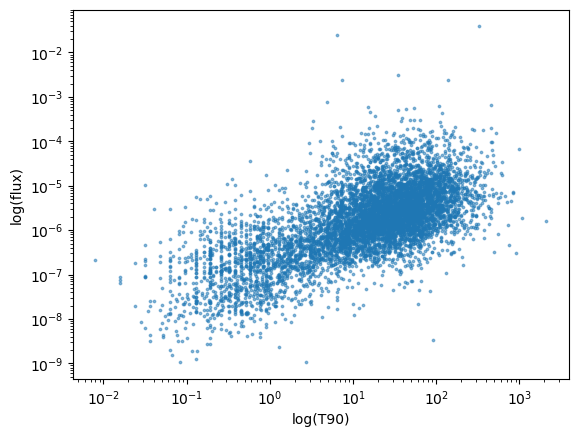

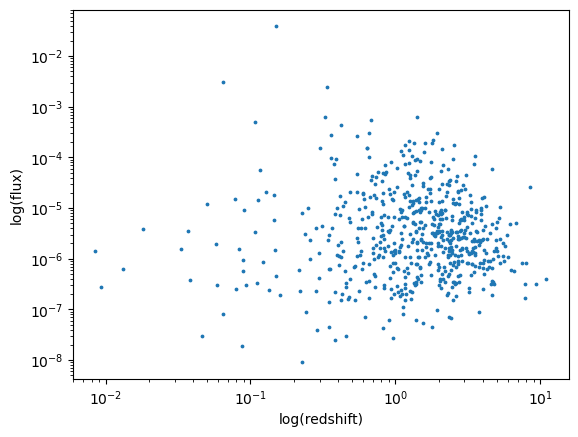

In [6]:
plt.scatter(time, flux, s=3, alpha=0.5)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('log(T90)')
plt.ylabel('log(flux)')
plt.show()
plt.scatter(rs, flux_rs, s=3, alpha=1)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('log(redshift)')
plt.ylabel('log(flux)')
plt.show()

Flux ('fluence') and emission duration ('T90') seems to underlying better the multi-modality of the distribution.

From the first plot it looks like the distribution contains two populations (infact we know two types of gamma-ray burst: shorts(<2s) and long(>2s)).

# K-means

In [7]:
#select the data != 0 for the conversion in log10 for the right functionality of the kmeans!
X = np.vstack([np.log10(time[(time!=0) & (flux!=0)]), np.log10(flux[(time!=0) & (flux!=0)])]).T
X_rs = np.vstack([np.log10(rs[(rs!=0) & (flux_rs!=0)]), np.log10(flux_rs[(rs!=0) & (flux_rs!=0)])]).T

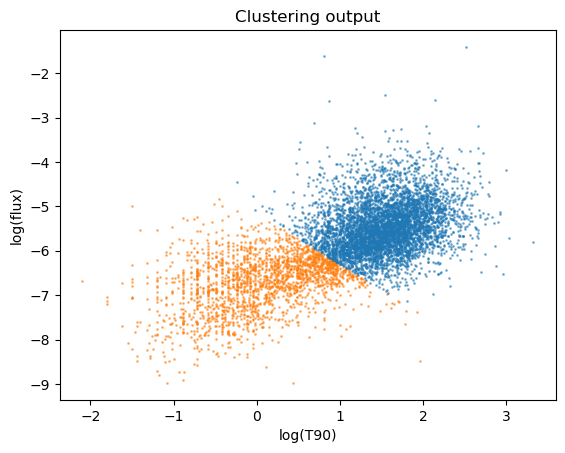

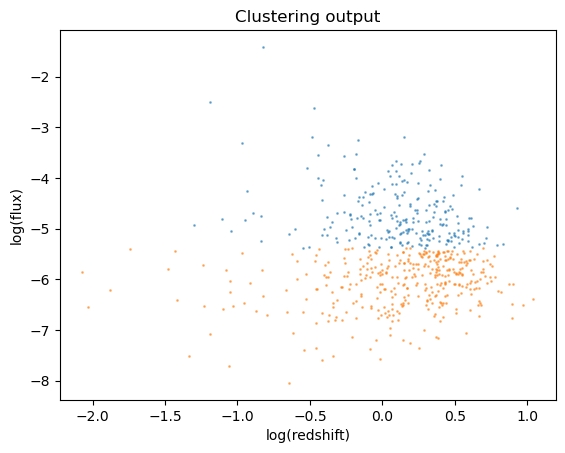

In [8]:
from sklearn.cluster import KMeans
from sklearn import preprocessing


#T90 and flux

clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], color=colors[ii],alpha=0.5, s=1)

plt.xlabel('log(T90)')
plt.ylabel('log(flux)')
plt.title('Clustering output')
plt.show()



#redshift and flux

clf_rs = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf_rs.fit(X_rs)
centers_rs = clf_rs.cluster_centers_ #location of the clusters
labels_rs = clf_rs.predict(X_rs) #labels for each of the points

# plot the data color-coded by cluster id
colors_rs = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X_rs[labels_rs==ii,0], X_rs[labels_rs==ii,1], color=colors_rs[ii],alpha=0.5, s=1)

plt.xlabel('log(redshift)')
plt.ylabel('log(flux)')
plt.title('Clustering output')
plt.show()

### With 2D histogram

In [9]:
#The StandardScaler transforms data so that its distribution has a mean of 0 and a standard deviation of 1.
#This is a crucial step in many machine learning algorithms, especially K-Means, because it prevents 
#features with larger scales from dominating the clustering process.

n_clusters = 2
scaler = preprocessing.StandardScaler()
clf = KMeans(n_clusters, n_init='auto')
clf.fit(scaler.fit_transform(X))

KMeans(n_clusters=2)

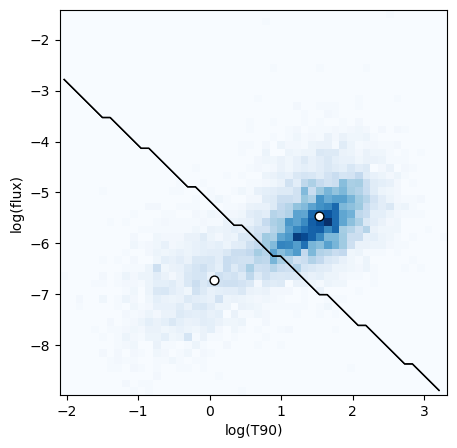

In [10]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X[:,0], X[:,1], 50)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto', 
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(clf.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, 50 * 50)).T

H = clf.predict(scaler.transform(Xgrid)).reshape((50, 50))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5], linewidths=1, colors='k')

    H = clf.predict(scaler.transform(Xgrid)).reshape((50, 50))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('log(T90)')
ax.set_ylabel('log(flux)')

plt.show()

# Mean-shift

### with estimated bandwidth

In [13]:
from sklearn.cluster import MeanShift, estimate_bandwidth

bandwidth = estimate_bandwidth(X)

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)
labels = ms.labels_
cluster_centers = ms.cluster_centers_

labels_unique = np.unique(labels)
n_clusters_ = len(labels_unique)

print("number of estimated clusters : %d" % n_clusters_)

number of estimated clusters : 3


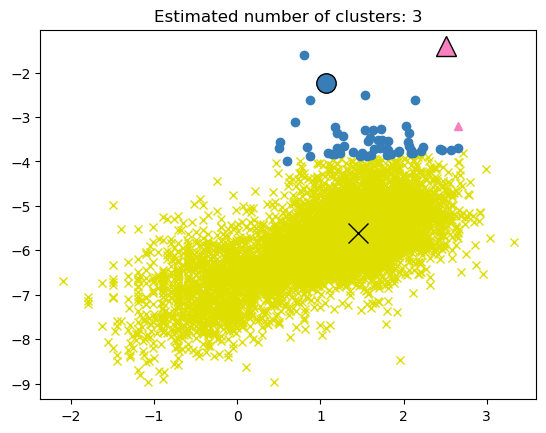

In [14]:
plt.figure(1)
plt.clf()

colors = ["#dede00", "#377eb8", "#f781bf", "green"]
markers = ["x", "o", "^", "*"]

for k, col in zip(range(n_clusters_), colors):
    my_members = labels == k
    cluster_center = cluster_centers[k]
    plt.plot(X[my_members, 0], X[my_members, 1], markers[k], color=col)
    plt.plot(
        cluster_center[0],
        cluster_center[1],
        markers[k],
        markerfacecolor=col,
        markeredgecolor="k",
        markersize=14,
    )
plt.title("Estimated number of clusters: %d" % n_clusters_)
plt.show()

Preatty bad clusering..

### with hand-choosen bandwidth

In [15]:
from sklearn.cluster import MeanShift

scaler = preprocessing.StandardScaler()
bandwidth = 1
#bandwidth = estimate_bandwidth(X_reduced) # this takes a long time...beware
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True, seeds=X, cluster_all=False)
ms.fit(scaler.fit_transform(X))

MeanShift(bandwidth=1, bin_seeding=True, cluster_all=False,
          seeds=array([[ 1.24708906, -5.0209709 ],
       [ 0.92675391, -4.5438618 ],
       [ 1.73865374, -5.80681973],
       ...,
       [ 0.49637605, -7.60453382],
       [ 2.31926433, -6.78225293],
       [ 0.71466499, -5.58410892]]))

[-1  0  1]
1
number of estimated clusters : 2


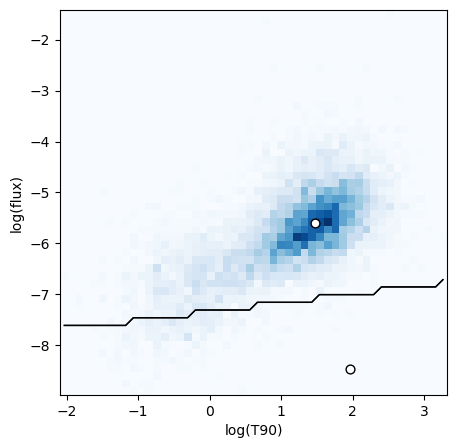

[[ 1.46681135 -5.61018141]
 [ 1.96151601 -8.47790804]]


In [16]:
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >=0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)
N=50
# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X[:,0], X[:,1], N)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, N * N)).T

H = ms.predict(scaler.transform(Xgrid)).reshape((N, N))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5], linewidths=1, colors='k')
 
    H = ms.predict(scaler.transform(Xgrid)).reshape((N, N))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('log(T90)')
ax.set_ylabel('log(flux)')

plt.show()
print(cluster_centers)

Maybe it doesn't respond well to outliers, cause it is not able to well detect the center of the left cluster. Let's try to cut out them.

## Cutting out outliers:

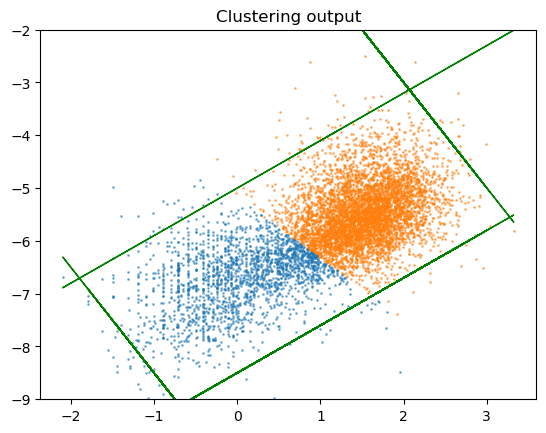

In [18]:
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], color=colors[ii],alpha=0.5, s=1)

x_f = X[:,0]
y_dw = (0.9)*x_f -8.5
plt.plot(x_f,y_dw, 'green', lw=1)

y_up = (0.9)*x_f -5
plt.plot(x_f,y_up, 'green', lw=1)

y_r = (-2)*x_f + 1
plt.plot(x_f,y_r, 'green', lw=1)

y_l = (-2)*x_f - 10.5
plt.plot(x_f,y_l, 'green', lw=1)

plt.title('Clustering output')
plt.ylim(-9,-2)
plt.show()

In [19]:
X_cut = X[((0.9*X[:,0] -8.5)<X[:,1]) & (X[:,1]<(0.9*X[:,0] -5)) & ((-2*X[:,0] -10.5)<X[:,1]) & ((-2*X[:,0] +1)>X[:,1])]

### with estimated bandwidth

In [22]:
bandwidth = estimate_bandwidth(X_cut)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X_cut)
labels = ms.labels_
cluster_centers = ms.cluster_centers_

labels_unique = np.unique(labels)
n_clusters_ = len(labels_unique)

print("number of estimated clusters : %d" % n_clusters_)

number of estimated clusters : 1


Very bad.. it estimates just one cluster

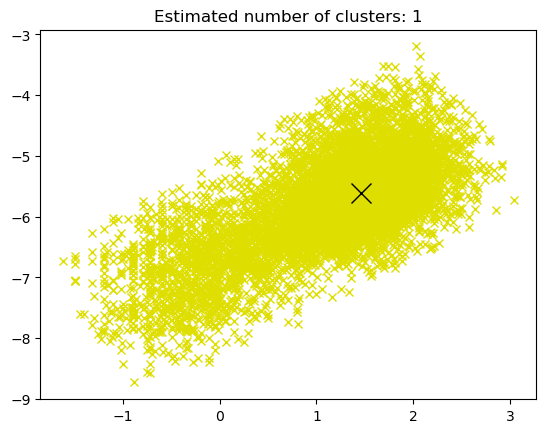

In [23]:
plt.figure(1)
plt.clf()

colors = ["#dede00", "#377eb8", "#f781bf", "green"]
markers = ["x", "o", "^", "*"]

for k, col in zip(range(n_clusters_), colors):
    my_members = labels == k
    cluster_center = cluster_centers[k]
    plt.plot(X_cut[my_members, 0], X_cut[my_members, 1], markers[k], color=col)
    plt.plot(
        cluster_center[0],
        cluster_center[1],
        markers[k],
        markerfacecolor=col,
        markeredgecolor="k",
        markersize=14,
    )
plt.title("Estimated number of clusters: %d" % n_clusters_)
plt.show()

### with hand-choosen bandwidth

In [24]:
bw_cut = 0.51
#bandwidth = estimate_bandwidth(X_reduced) # this takes a long time...beware
ms_cut = MeanShift(bandwidth=bw_cut, bin_seeding=True, cluster_all=False)
ms_cut.fit(scaler.fit_transform(X_cut))

MeanShift(bandwidth=0.51, bin_seeding=True, cluster_all=False)

[-1  0  1]
0.51
number of estimated clusters : 2


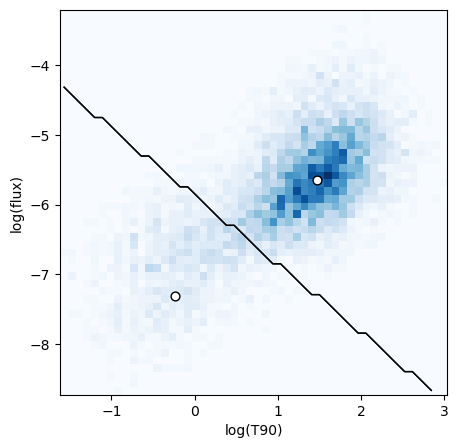

[[ 1.47652775 -5.64713778]
 [-0.23424246 -7.31944785]]


In [25]:
labels_unique = np.unique(ms_cut.labels_)
n_clusters = len(labels_unique[labels_unique >=0])
print(labels_unique)
print(bw_cut)
print("number of estimated clusters :", n_clusters)
N=50
# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X_cut[:,0], X_cut[:,1], N)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(ms_cut.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, N * N)).T

H = ms_cut.predict(scaler.transform(Xgrid)).reshape((N, N))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5], linewidths=1, colors='k')
 
    H = ms_cut.predict(scaler.transform(Xgrid)).reshape((N, N))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('log(T90)')
ax.set_ylabel('log(flux)')

plt.show()
print(cluster_centers)

Way better! It actually does not well responds to outlyers